In [9]:
import pybaseball as pb
import pandas as pd
import numpy as np

start_dt = '2025-03-27'
end_dt = '2025-09-29'
test_dt = '2025-09-01'

#this helps make sure if there is an error we can pick up where we left off rather than restarting
pb.cache.enable()

In [10]:
#pull the statcast data
df_sc = pb.statcast(start_dt=start_dt,end_dt=end_dt)

This is a large query, it may take a moment to complete


100%|██████████| 187/187 [01:35<00:00,  1.96it/s]


In [11]:
#create a data frame that cleans the data for use in the model

#documentation: https://baseballsavant.mlb.com/csv-docs

df_sc_c = df_sc[df_sc['type'] == 'X'].copy()

#fill in NA's with 0's. This method allows us to not get copy warnings
df_sc_c.loc[:, 'launch_speed'] = df_sc_c['launch_speed'].fillna(0)

#create a column 
df_sc_c["hard_hit"] = (df_sc_c["launch_speed"] >= 95).astype(int)

#get a subset of relevant fields for use in the model
df_sc_c_m = df_sc_c[['game_date','pitch_type','launch_angle','release_speed','release_pos_x','release_pos_z','release_pos_y','plate_x','plate_z','release_spin_rate','release_extension','stand','p_throws','hard_hit','balls','strikes']]

df_sc_c_m.head()

,game_date,pitch_type,launch_angle,release_speed,release_pos_x,release_pos_z,release_pos_y,plate_x,plate_z,release_spin_rate,release_extension,stand,p_throws,hard_hit,balls,strikes
2023,2025-09-28,FF,37,95.7,-2.15,5.21,54.67,-0.395886,3.083176,2370,5.8,L,R,0,0,0
2465,2025-09-28,SI,-11,95.2,-2.38,4.77,54.37,0.736511,1.984434,2148,6.1,R,R,0,2,2
1527,2025-09-28,FF,-6,97.6,-2.38,5.96,53.85,0.705669,1.997782,2454,6.7,L,R,0,1,0
1638,2025-09-28,SL,0,87.5,-2.39,6.03,53.73,-0.373106,2.276259,2546,6.8,L,R,0,2,2
3723,2025-09-28,FC,1,90.9,-3.27,5.5,53.59,0.2404,2.488524,2458,6.9,L,R,0,0,0


Clean Data

In [12]:
#Clean the pitch type and convert it to a number

#print unique value counts
#print(df_sc_c_m['pitch_type'].value_counts())

#not having a pitch type is problematic, it doesn't look like there are many of these records so let's just remove them
df_sc_c_m.dropna(subset=["pitch_type"], inplace=True)

#create a datafrmae with the values in the pitch_type column
df_pt = pd.DataFrame(df_sc_c_m['pitch_type'].unique())

#now make a column for the ID number
df_pt['pitch_type_id'] = df_pt.index

#rename the pitch type column
df_pt.rename(columns={0: 'pitch_type'}, inplace=True) 

df_pt

,pitch_type,pitch_type_id
0,FF,0
1,SI,1
2,SL,2
3,FC,3
4,CH,4
5,SV,5
6,ST,6
7,CU,7
8,FS,8
9,KC,9


In [13]:
#clean the stand and p_throw and turn into a numeric variable

#convert stand variable, which refers to the batter, to numeric
df_sc_c_m['stand_R'] = df_sc_c_m['stand'].map({'L': 0, 'R': 1})

#this creates a new feature that converts the plate_x variable into an inside pitch variable because the horizontal position can mean
#very different things for a right handed vs. left handed pitcher
df_sc_c_m["inside_pitch"] = df_sc_c_m["plate_x"] * (1 - 2 * df_sc_c_m["stand_R"])

#this creates a new feature that shows the absolute value of the horizontal position, so smaller values mean it's closer to the middle
df_sc_c_m["plate_x_abs"] = df_sc_c_m["plate_x"].abs()

#convert p_throws variable to numeric
df_sc_c_m['p_throws_R'] = df_sc_c_m['p_throws'].map({'L': 0, 'R': 1})

#join the df_pt dataframe to convert the pitch type to a numeric variable
df_sc_c_m_f = df_sc_c_m.merge(df_pt, how='left', on='pitch_type')

#drop these two columns so we can get rid of the text columns
df_sc_c_m_f = df_sc_c_m_f.drop(columns=['stand', 'p_throws','pitch_type'])

df_sc_c_m_f.tail()


,game_date,launch_angle,release_speed,release_pos_x,release_pos_z,release_pos_y,plate_x,plate_z,release_spin_rate,release_extension,hard_hit,balls,strikes,stand_R,inside_pitch,plate_x_abs,p_throws_R,pitch_type_id
124760,2025-03-27,6,93.6,3.0,4.77,54.04,-0.166754,2.082585,2307,6.5,0,1,0,1,0.166754,0.166754,0,0
124761,2025-03-27,-80,88.2,-3.07,5.45,54.53,-1.610185,3.048594,2147,6.0,0,1,2,0,-1.610185,1.610185,1,4
124762,2025-03-27,-19,88.4,-3.24,5.43,54.51,-1.512531,2.106788,2073,6.0,1,2,2,0,-1.512531,1.512531,1,4
124763,2025-03-27,18,88.9,-3.13,5.44,54.33,-0.001412,1.892134,2101,6.2,1,2,1,1,0.001412,0.001412,1,4
124764,2025-03-27,-11,87.3,-3.25,5.4,54.59,-0.285129,1.713766,2042,5.9,1,1,1,0,-0.285129,0.285129,1,4


In [14]:
#need to make all the columns numeric, drop certain columns and convert others to numbers

#check for each column how many records are NA
for i in df_sc_c_m_f.columns:
    print(i, df_sc_c_m_f[df_sc_c_m_f[i].isna()].shape)


game_date (0, 18)
launch_angle (332, 18)
release_speed (0, 18)
release_pos_x (0, 18)
release_pos_z (0, 18)
release_pos_y (0, 18)
plate_x (0, 18)
plate_z (0, 18)
release_spin_rate (338, 18)
release_extension (15, 18)
hard_hit (0, 18)
balls (0, 18)
strikes (0, 18)
stand_R (0, 18)
inside_pitch (0, 18)
plate_x_abs (0, 18)
p_throws_R (0, 18)
pitch_type_id (0, 18)


In [15]:
#drop the rows with NA values since the record counts are low
df_sc_c_m_f = df_sc_c_m_f.dropna(subset=['launch_angle', 'release_spin_rate','release_extension'])

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [17]:
#final steps for data to be used in the model

#create the X train (contains features) and test data sets
#the train/test split is based on the testing date set above in the first cell
X_train = df_sc_c_m_f[df_sc_c_m_f['game_date'] < test_dt].copy()
X_test = df_sc_c_m_f[df_sc_c_m_f['game_date'] >= test_dt].copy()

#create the Y (actual result) train and test data sets
y_train = X_train[['hard_hit']]
y_test = X_test[['hard_hit']]

#drop the actual result value from the X train set
X_train.drop(columns=['hard_hit','game_date'], inplace=True)
X_test.drop(columns=['hard_hit','game_date'], inplace=True)


In [ ]:
#set up the model to train

# 1. Initialize the model
xgb_model = XGBClassifier(
    objective="binary:logistic",
    max_depth=5,
    learning_rate=0.05, #
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# 2. Train the model
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.66792	validation_1-logloss:0.66858
[50]	validation_0-logloss:0.54661	validation_1-logloss:0.55287
[100]	validation_0-logloss:0.53050	validation_1-logloss:0.54023
[150]	validation_0-logloss:0.52380	validation_1-logloss:0.53686
[200]	validation_0-logloss:0.51926	validation_1-logloss:0.53520
[250]	validation_0-logloss:0.51524	validation_1-logloss:0.53416
[299]	validation_0-logloss:0.51202	validation_1-logloss:0.53368


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Evaluation and Testing

In [19]:
# 3. Make predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

In [20]:
# 4. Evaluate
#I tried a few different adjustments with the hyperparameters and this seemed to perform as good as any other combination
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC AUC: 0.7913430805346308
Accuracy: 0.7195148017526986
              precision    recall  f1-score   support

           0       0.77      0.75      0.76     11018
           1       0.65      0.68      0.67      7696

    accuracy                           0.72     18714
   macro avg       0.71      0.71      0.71     18714
weighted avg       0.72      0.72      0.72     18714



In [21]:
#this section gives insight into how much each feature matters to prediction performance
#it measures how much performance drops if you scramble each feature

from sklearn.inspection import permutation_importance

result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance.head(15))


launch_angle         0.163431
inside_pitch         0.036872
plate_z              0.035132
plate_x_abs          0.033370
pitch_type_id        0.008779
release_speed        0.004978
strikes              0.004246
plate_x              0.002150
stand_R              0.001582
release_pos_x        0.001467
balls                0.001085
release_spin_rate    0.000659
release_pos_y        0.000183
p_throws_R           0.000148
release_extension    0.000102
dtype: float64


c:\Users\matth\kempalytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


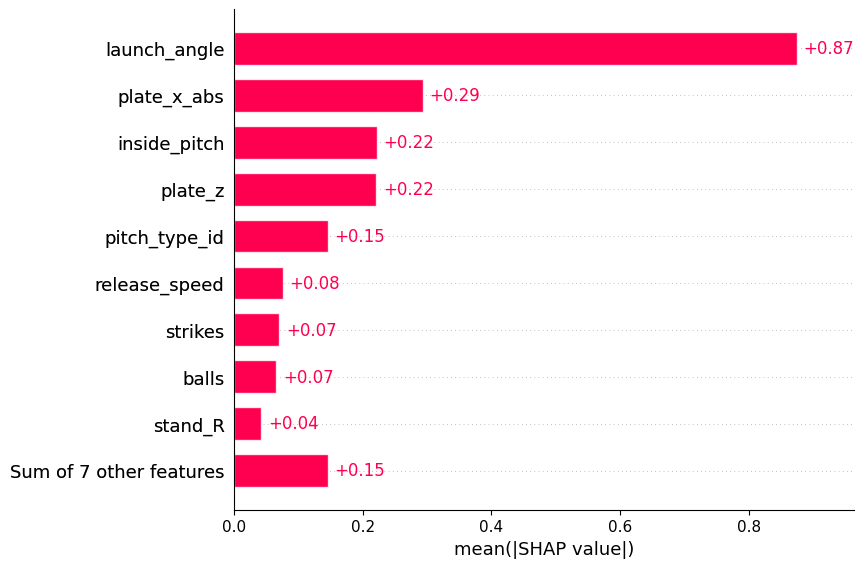

In [22]:
#shap gives global feature importance, direction, nonlinear effects, and interaction patterns to help analyze which features are most
#important to showing what results in a hard hit ball
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

#plot the result
shap.plots.bar(shap_values)


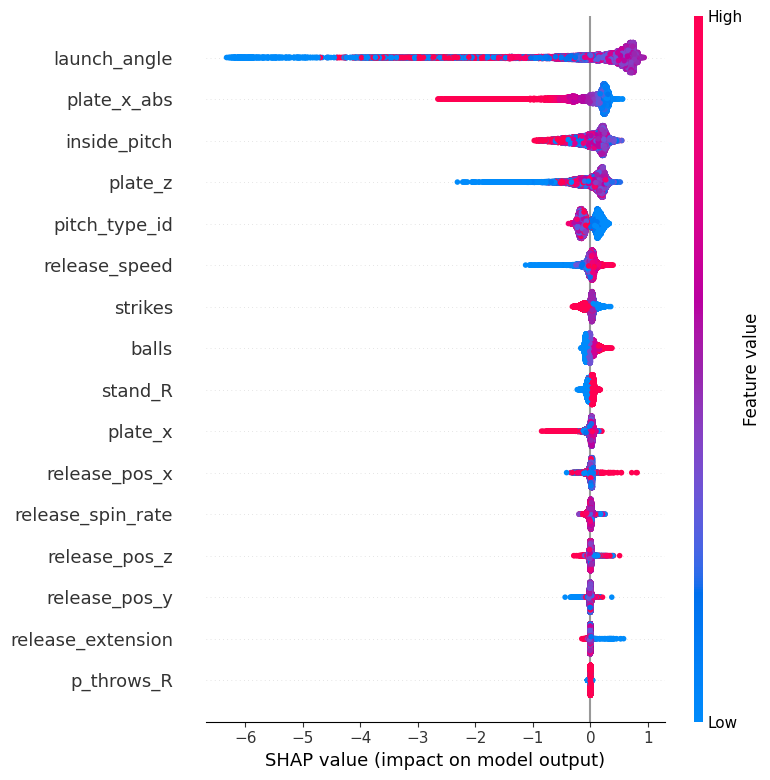

In [23]:
#this gives us more insight into what features had more influence
shap.summary_plot(shap_values, X_test)


Refactored model looking at only pitch quality related features because I want to keep this to things in the pitcher's control

In [24]:
#drop the launch_angle feature since this occurs after the batter hits the ball, we'd like to focus more on pitch attributes
df_sc_c_m_f_pq = df_sc_c_m_f.drop(columns=('launch_angle'))

df_sc_c_m_f_pq.head()

,game_date,release_speed,release_pos_x,release_pos_z,release_pos_y,plate_x,plate_z,release_spin_rate,release_extension,hard_hit,balls,strikes,stand_R,inside_pitch,plate_x_abs,p_throws_R,pitch_type_id
0,2025-09-28,95.7,-2.15,5.21,54.67,-0.395886,3.083176,2370,5.8,0,0,0,0,-0.395886,0.395886,1,0
1,2025-09-28,95.2,-2.38,4.77,54.37,0.736511,1.984434,2148,6.1,0,2,2,1,-0.736511,0.736511,1,1
2,2025-09-28,97.6,-2.38,5.96,53.85,0.705669,1.997782,2454,6.7,0,1,0,0,0.705669,0.705669,1,0
3,2025-09-28,87.5,-2.39,6.03,53.73,-0.373106,2.276259,2546,6.8,0,2,2,0,-0.373106,0.373106,1,2
4,2025-09-28,90.9,-3.27,5.5,53.59,0.2404,2.488524,2458,6.9,0,0,0,0,0.2404,0.2404,1,3


In [25]:
#final steps for data to be used in the model

#create the X train (contains features) and test data sets
X_train = df_sc_c_m_f_pq[df_sc_c_m_f_pq['game_date'] < test_dt].copy()
X_test = df_sc_c_m_f_pq[df_sc_c_m_f_pq['game_date'] >= test_dt].copy()

#create the Y (actual result) train and test data sets
y_train = X_train[['hard_hit']]
y_test = X_test[['hard_hit']]

#drop the actual result value from the X train set
X_train.drop(columns=['hard_hit','game_date'], inplace=True)
X_test.drop(columns=['hard_hit','game_date'], inplace=True)

In [26]:
#set up the model to train

# 1. Initialize the model
xgb_model = XGBClassifier(
    objective="binary:logistic",
    max_depth=5,
    learning_rate=0.03, #
    n_estimators=600,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

#original
#xgb_model = XGBClassifier(
#    objective="binary:logistic",
#    max_depth=5,
#    learning_rate=0.05,
#    n_estimators=300,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    eval_metric="logloss",
#    random_state=42,
#    n_jobs=-1
#)

# 2. Train the model
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.67407	validation_1-logloss:0.67455
[50]	validation_0-logloss:0.62231	validation_1-logloss:0.62497
[100]	validation_0-logloss:0.61268	validation_1-logloss:0.61754
[150]	validation_0-logloss:0.60844	validation_1-logloss:0.61533
[200]	validation_0-logloss:0.60540	validation_1-logloss:0.61425
[250]	validation_0-logloss:0.60292	validation_1-logloss:0.61363
[300]	validation_0-logloss:0.60075	validation_1-logloss:0.61321
[350]	validation_0-logloss:0.59868	validation_1-logloss:0.61306
[400]	validation_0-logloss:0.59678	validation_1-logloss:0.61295
[450]	validation_0-logloss:0.59484	validation_1-logloss:0.61284
[500]	validation_0-logloss:0.59292	validation_1-logloss:0.61287
[550]	validation_0-logloss:0.59109	validation_1-logloss:0.61291
[599]	validation_0-logloss:0.58934	validation_1-logloss:0.61297


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [27]:
# 3. Make predictions
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

In [ ]:
# 4. Evaluate
#I once again tried a few different adjustments with the hyperparameters
#even though precision and recall are lower in this version than the previous one, I felt that including launch angle was creating some
#model leakage because that occurs after the ball is hit
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC AUC: 0.6958762539488397
Accuracy: 0.6444907555840547
              precision    recall  f1-score   support

           0       0.68      0.74      0.71     11018
           1       0.58      0.51      0.54      7696

    accuracy                           0.64     18714
   macro avg       0.63      0.62      0.63     18714
weighted avg       0.64      0.64      0.64     18714



Do some checks to determine how much each feature matters in prediction to help us better understand what elements of a pitch contribute to hard hit balls

In [29]:
#this section gives insight into how much each feature matters to prediction performance
#it measures how much performance drops if you scramble each feature
result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance.head(15))

plate_x_abs          0.066411
plate_z              0.050618
inside_pitch         0.047076
pitch_type_id        0.016128
release_speed        0.007095
plate_x              0.005069
strikes              0.005039
release_pos_x        0.002526
stand_R              0.002220
release_spin_rate    0.001569
balls                0.001276
release_pos_z        0.000640
release_pos_y        0.000346
p_throws_R           0.000311
release_extension    0.000267
dtype: float64


Use Shap to help explain the results, leveraging explainer and dependency charts

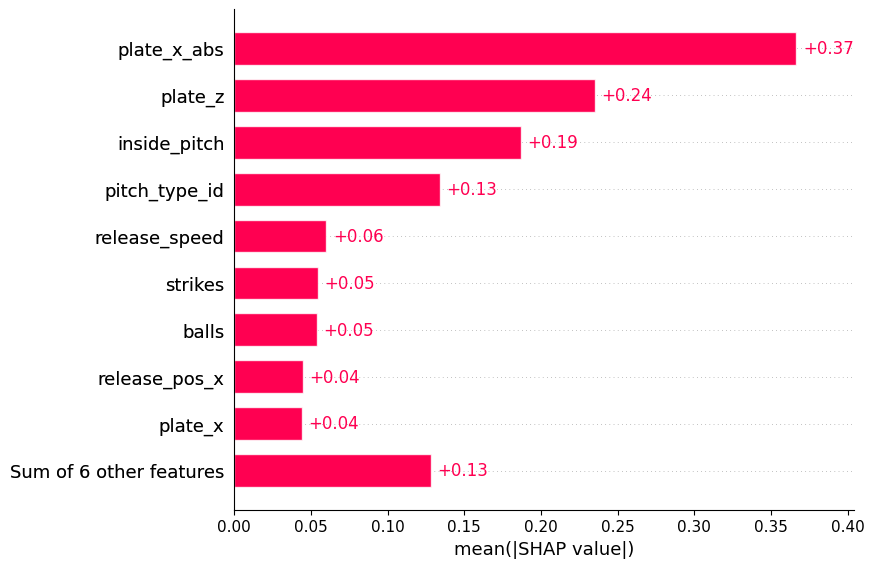

In [30]:
#create a visual to help explain the features and how they influenced the results

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

#plot the result
shap.plots.bar(shap_values)

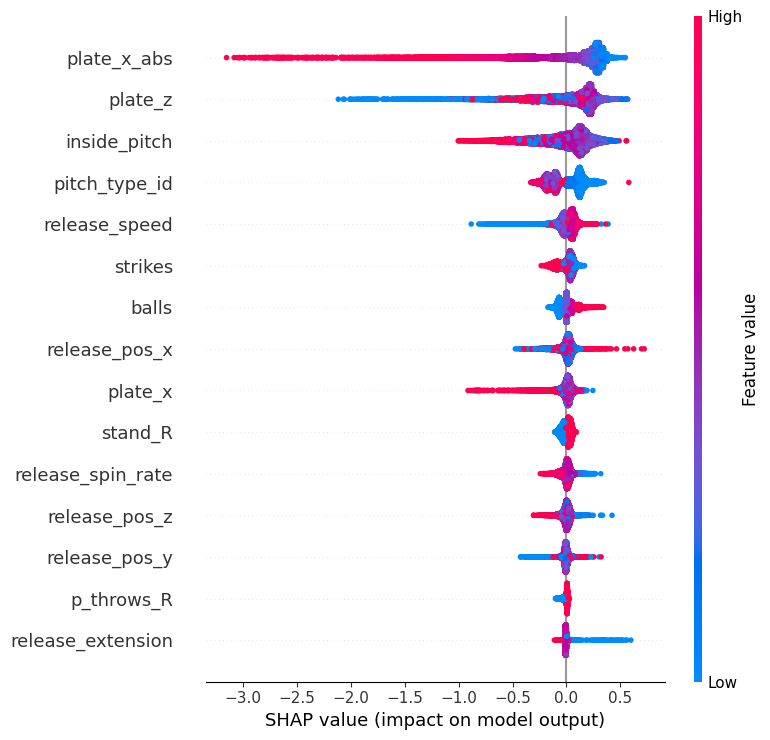

In [31]:
#this gives us more insight into what features had more influence
#shap measures for a specific prediction, how much does each feature push the probability up or down
shap.summary_plot(shap_values, X_test)

Create a Shap dependence plot on inside pitch

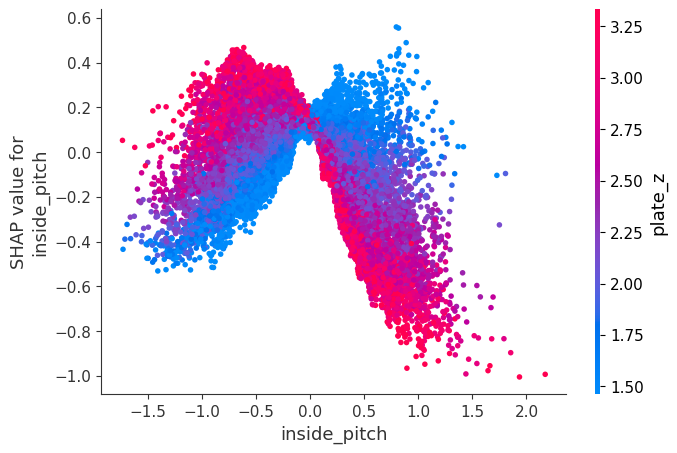

In [32]:
#shap.dependence_plot("plate_z", shap_values.values, X_test)
shap.dependence_plot("inside_pitch", shap_values.values, X_test)

Create a Shap dependence plot on plate_z and plate_x_abs since those are the two highest impacting features

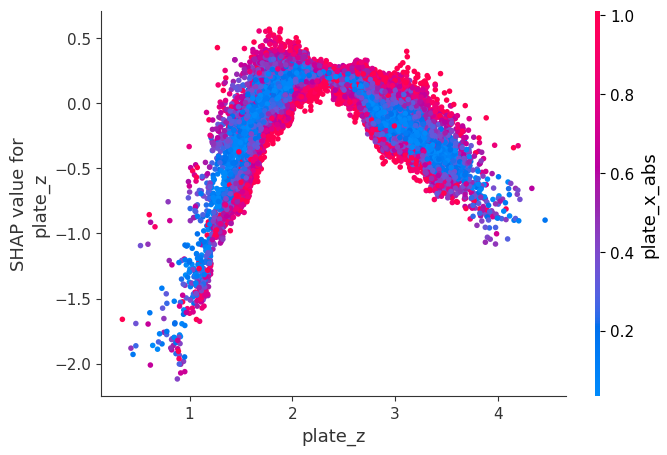

In [39]:
shap.dependence_plot(
    "plate_z",
    shap_values.values,
    X_test,
    interaction_index="plate_x_abs"
)
